## Projet Maintenance Prédictive
### Étape 1 — Chargement et Exploration des Données (EDA)

**Dataset :** Condition Monitoring of Hydraulic Systems (UCI)  
**Objectif :** Prédire si la condition de la valve est optimale (100%) ou non  
**Contrainte :** Les 2000 premiers cycles → entraînement | Cycles restants → test final


### 1 - Imports et configuration

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration affichage
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.facecolor'] = '#f8fafc'
plt.rcParams['axes.facecolor'] = '#f1f5f9'

print("Imports OK")


Imports OK


### 2. Chargement des données

Les 3 fichiers fournis :
- **PS2.txt** : Capteur de pression — 100 Hz → 6000 points par cycle de 60s
- **FS1.txt** : Capteur de débit volumique — 10 Hz → 600 points par cycle de 60s
- **profile.txt** : Variables cibles (dont `valve condition`)


In [23]:
# Adapter ce chemin selon votre arborescence
DATA_PATH = "../data/raw/"

# Chargement PS2 — Pression (bar), 100 Hz
ps2 = pd.read_csv(DATA_PATH + "PS2.txt", sep='\t', header=None)
print(f"PS2  chargé : {ps2.shape[0]} cycles x {ps2.shape[1]} timesteps")

# Chargement FS1 — Débit (L/min), 10 Hz
fs1 = pd.read_csv(DATA_PATH + "FS1.txt", sep='\t', header=None)
print(f"FS1  chargé : {fs1.shape[0]} cycles x {fs1.shape[1]} timesteps")

# Chargement profile — variables cibles
profile = pd.read_csv(
    DATA_PATH + "profile.txt", sep='\t', header=None,
    names=['cooler', 'valve', 'pump', 'accumulator', 'stable']
)
print(f"Profile chargé : {profile.shape[0]} cycles x {profile.shape[1]} variables")


PS2  chargé : 2205 cycles x 6000 timesteps
FS1  chargé : 2205 cycles x 600 timesteps
Profile chargé : 2205 cycles x 5 variables


### 3. Aperçu des données

In [24]:
print("--- 5 premières lignes de PS2 ---")
ps2.head()

--- 5 premières lignes de PS2 ---


,0,1,2,3,4,5,6,7,8,9,...,5990,5991,5992,5993,5994,5995,5996,5997,5998,5999
0,125.5000,125.3900,125.4000,125.0300,124.0500,123.1800,104.0100,56.5000,23.9920,18.4060,...,125.0200,125.0000,125.1000,125.0900,124.9800,124.9100,124.9800,125.1100,125.1400,125.1000
1,125.0600,125.0800,125.0900,124.6900,123.8400,123.1400,103.6300,63.6870,28.3590,21.7110,...,124.8000,124.8800,125.1300,125.2200,125.0900,124.9800,125.0600,125.1300,125.0900,125.0400
2,125.1300,125.2700,125.2300,124.7400,123.9400,123.2300,106.3500,60.5160,26.2580,19.2580,...,124.6100,124.6900,124.7400,124.7100,124.5900,124.6400,124.7400,124.7300,124.7700,124.8800
3,124.9300,124.9600,124.9200,124.4100,123.6000,122.8800,103.9900,58.8590,27.7810,21.4690,...,124.8200,124.7900,124.6900,124.6900,124.7700,124.8300,124.6900,124.5300,124.5100,124.5900
4,124.7200,124.7400,124.6600,124.3100,123.5700,122.7400,105.9400,62.6480,30.8750,23.8830,...,124.8000,124.6700,124.4900,124.5600,124.6900,124.6200,124.4500,124.4100,124.4700,124.5100


In [25]:
print("\n--- 5 premières lignes de FS1 ---")
fs1.head()



--- 5 premières lignes de FS1 ---


,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,8.9900,0.7700,0.6410,0.0060,0.0000,0.0000,0.0010,0.0030,0.0010,0.0010,...,7.7430,7.9920,7.9190,7.7730,7.9550,7.8230,7.9630,7.8760,7.7380,8.0360
1,8.9190,0.8150,0.7090,0.0090,0.0040,0.0000,0.0010,0.0000,0.0000,0.0010,...,7.8310,8.0030,7.9230,7.7450,7.8670,7.7470,7.9690,7.9690,7.9630,7.8900
2,9.1790,0.6830,0.5280,0.0080,0.0030,0.0010,0.0030,0.0030,0.0040,0.0060,...,7.8620,7.8150,7.8940,7.7430,7.9360,7.7700,7.9820,7.8730,7.8980,7.9520
3,9.0340,0.7280,0.5950,0.0090,0.0010,0.0040,0.0030,0.0030,0.0030,0.0010,...,7.6310,7.9490,7.7730,8.0540,7.8270,8.0110,7.9190,7.9380,7.8770,7.7730
4,8.7290,0.7050,0.4460,0.0140,0.0070,0.0030,0.0010,0.0030,0.0010,0.0000,...,7.7710,7.9360,7.9190,7.9460,7.8040,7.9830,7.8380,7.8820,7.8940,7.8250


In [26]:

print("\n--- 5 premières lignes de Profile ---")
profile.head()


--- 5 premières lignes de Profile ---


,cooler,valve,pump,accumulator,stable
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


In [27]:
print("=== 5 premières lignes de PS2 (6000 colonnes, affichage tronqué) ===")
ps2.iloc[:5, :10]


=== 5 premières lignes de PS2 (6000 colonnes, affichage tronqué) ===


,0,1,2,3,4,5,6,7,8,9
0,125.5000,125.3900,125.4000,125.0300,124.0500,123.1800,104.0100,56.5000,23.9920,18.4060
1,125.0600,125.0800,125.0900,124.6900,123.8400,123.1400,103.6300,63.6870,28.3590,21.7110
2,125.1300,125.2700,125.2300,124.7400,123.9400,123.2300,106.3500,60.5160,26.2580,19.2580
3,124.9300,124.9600,124.9200,124.4100,123.6000,122.8800,103.9900,58.8590,27.7810,21.4690
4,124.7200,124.7400,124.6600,124.3100,123.5700,122.7400,105.9400,62.6480,30.8750,23.8830


### 4. Informations générales et types

In [28]:
print("─── PS2 ───")
print(f"  Shape       : {ps2.shape}")
print(f"  Durée cycle : {ps2.shape[1] / 100} secondes (100 Hz)")
print(f"  Dtype       : {ps2.dtypes.unique()}")
print(f"  Mémoire     : {ps2.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n─── FS1 ───")
print(f"  Shape       : {fs1.shape}")
print(f"  Durée cycle : {fs1.shape[1] / 10} secondes (10 Hz)")
print(f"  Dtype       : {fs1.dtypes.unique()}")
print(f"  Mémoire     : {fs1.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n─── Profile ───")
print(f"  Shape       : {profile.shape}")
profile.dtypes


─── PS2 ───
  Shape       : (2205, 6000)
  Durée cycle : 60.0 secondes (100 Hz)
  Dtype       : [dtype('float64')]
  Mémoire     : 105.8 MB

─── FS1 ───
  Shape       : (2205, 600)
  Durée cycle : 60.0 secondes (10 Hz)
  Dtype       : [dtype('float64')]
  Mémoire     : 10.6 MB

─── Profile ───
  Shape       : (2205, 5)


cooler         int64
valve          int64
pump           int64
accumulator    int64
stable         int64
dtype: object

## 5. Vérification des valeurs manquantes

In [29]:
print(f"NaN dans PS2     : {ps2.isna().sum().sum()}")
print(f"NaN dans FS1     : {fs1.isna().sum().sum()}")
print(f"NaN dans profile : {profile.isna().sum().sum()}")
print()
print("Détail profile :")
print(profile.isna().sum())


NaN dans PS2     : 0
NaN dans FS1     : 0
NaN dans profile : 0

Détail profile :
cooler         0
valve          0
pump           0
accumulator    0
stable         0
dtype: int64


aucune valeur manquante super bonne nouvelle

## 6. Statistiques descriptives

In [30]:
# Statistiques globales sur PS2 (en aplatissant toutes les valeurs)
ps2_flat = ps2.values.flatten()
print("=== PS2 — Pression (bar) ===")
print(f"  Min    : {ps2_flat.min():.4f}")
print(f"  Max    : {ps2_flat.max():.4f}")
print(f"  Moyenne: {ps2_flat.mean():.4f}")
print(f"  Std    : {ps2_flat.std():.4f}")

# Statistiques globales sur FS1
fs1_flat = fs1.values.flatten()
print("\n=== FS1 — Débit (L/min) ===")
print(f"  Min    : {fs1_flat.min():.4f}")
print(f"  Max    : {fs1_flat.max():.4f}")
print(f"  Moyenne: {fs1_flat.mean():.4f}")
print(f"  Std    : {fs1_flat.std():.4f}")

# Statistiques profile
print("\n=== Profile — statistiques descriptives ===")
print(profile.describe())


=== PS2 — Pression (bar) ===
  Min    : 0.0000
  Max    : 167.7700
  Moyenne: 109.3799
  Std    : 48.1032

=== FS1 — Débit (L/min) ===
  Min    : 0.0000
  Max    : 20.4790
  Moyenne: 6.1985
  Std    : 3.2138

=== Profile — statistiques descriptives ===
         cooler     valve      pump  accumulator    stable
count 2205.0000 2205.0000 2205.0000    2205.0000 2205.0000
mean    41.2408   90.6939    0.6694     107.1995    0.3429
std     42.3831   10.6818    0.8172      16.4358    0.4748
min      3.0000   73.0000    0.0000      90.0000    0.0000
25%      3.0000   80.0000    0.0000      90.0000    0.0000
50%     20.0000  100.0000    0.0000     100.0000    0.0000
75%    100.0000  100.0000    1.0000     130.0000    1.0000
max    100.0000  100.0000    2.0000     130.0000    1.0000


PS2 (Pression) : La pression varie énormément, allant de 0 à 167 bar. Une moyenne de 109 bar avec un écart-type (Std) élevé de 48 bar indique que le système subit de fortes montées et descentes de pression au cours d'un cycle de 60 secondes. C'est typique d'un système qui travaille par phases (compression/décompression).

FS1 (Débit) :Le débit est relativement faible (moyenne de 6,2 L/min) avec un maximum à 20,48 L/min. La présence d'un minimum à 0.00 suggère qu'il y a des moments dans le cycle où le liquide ne circule plus du tout (valve fermée).


Profile : La Condition de la Valve (Cible). Regardons la colonne valve :La Plage : Elle varie de 73% (très dégradée) à 100% (optimale).La Répartition :
 * La médiane (50%) est à 100.0.
 * Le 25ème percentile est à 80.0.Interprétation : Cela signifie que pour plus de la moitié de vos cycles, la valve est en parfait état (100%). Cependant, au moins 25% des cycles montrent une valve dégradée à 80% ou moins. notre modèle devra apprendre à détecter précisément ce qui différencie ces deux états dans les signaux PS2 et FS1.

## 7. Analyse de la variable cible — Valve Condition

La valve condition prend 4 valeurs :
| Valeur | Signification |
|--------|--------------|
| 100 | Comportement optimal |
| 90  | Petit retard |
| 80  | Retard sévère |
| 73  | Proche de la défaillance totale |

**Cible binaire :** `valve = 100` → classe 1 (optimal) | `valve ≠ 100` → classe 0 (non optimal)


In [36]:
print("=== Distribution des 4 classes ===")
valve_counts = profile['valve'].value_counts().sort_index()
print(valve_counts)
print()

# Création de la cible binaire
profile['valve_optimal'] = (profile['valve'] == 100).astype(int)

print("=== Cible binaire ===")
binary = profile['valve_optimal'].value_counts().sort_index()
print(f"  Classe 0 (non optimal) : {binary[0]} cycles ({binary[0]/len(profile)*100:.1f}%)")
print(f"  Classe 1 (optimal)     : {binary[1]} cycles ({binary[1]/len(profile)*100:.1f}%)")
print()
print("Ratio : {:.3f}  → Classes bien équilibrées".format(binary[0]/binary[1]))


=== Distribution des 4 classes ===
valve
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

=== Cible binaire ===
  Classe 0 (non optimal) : 1080 cycles (49.0%)
  Classe 1 (optimal)     : 1125 cycles (51.0%)

Ratio : 0.960  → Classes bien équilibrées


## 8. Analyse du Stable Flag

Le flag `stable` indique si les conditions étaient stables lors du cycle :
- `0` → conditions stables
- `1` → conditions potentiellement instables (à surveiller)


In [32]:
print("=== Distribution stable flag ===")
print(profile['stable'].value_counts())
print()
print("=== Croisement stable / valve_optimal ===")
cross = pd.crosstab(profile['stable'], profile['valve_optimal'], 
                    rownames=['stable'], colnames=['valve_optimal'])
print(cross)
print()
print("En proportions :")
print(pd.crosstab(profile['stable'], profile['valve_optimal'], normalize='index').round(3))


=== Distribution stable flag ===
stable
0    1449
1     756
Name: count, dtype: int64

=== Croisement stable / valve_optimal ===
valve_optimal     0    1
stable                  
0              1080  369
1                 0  756

En proportions :
valve_optimal      0      1
stable                     
0             0.7450 0.2550
1             0.0000 1.0000


Quand stable = 0 (Système instable) : La situation est partagée.1080 cycles ont une valve défectueuse (0).369 cycles ont une valve optimale (1) mais le système est quand même instable.Traduction : Une valve optimale n'est pas une garantie de stabilité (d'autres composants comme la pompe ou le refroidisseur peuvent créer de l'instabilité), mais une valve défaillante provoque systématiquement une instabilité.

## 9. Visualisation des signaux bruts

On trace quelques cycles pour chaque classe afin de voir si les signaux sont visuellement différenciables.


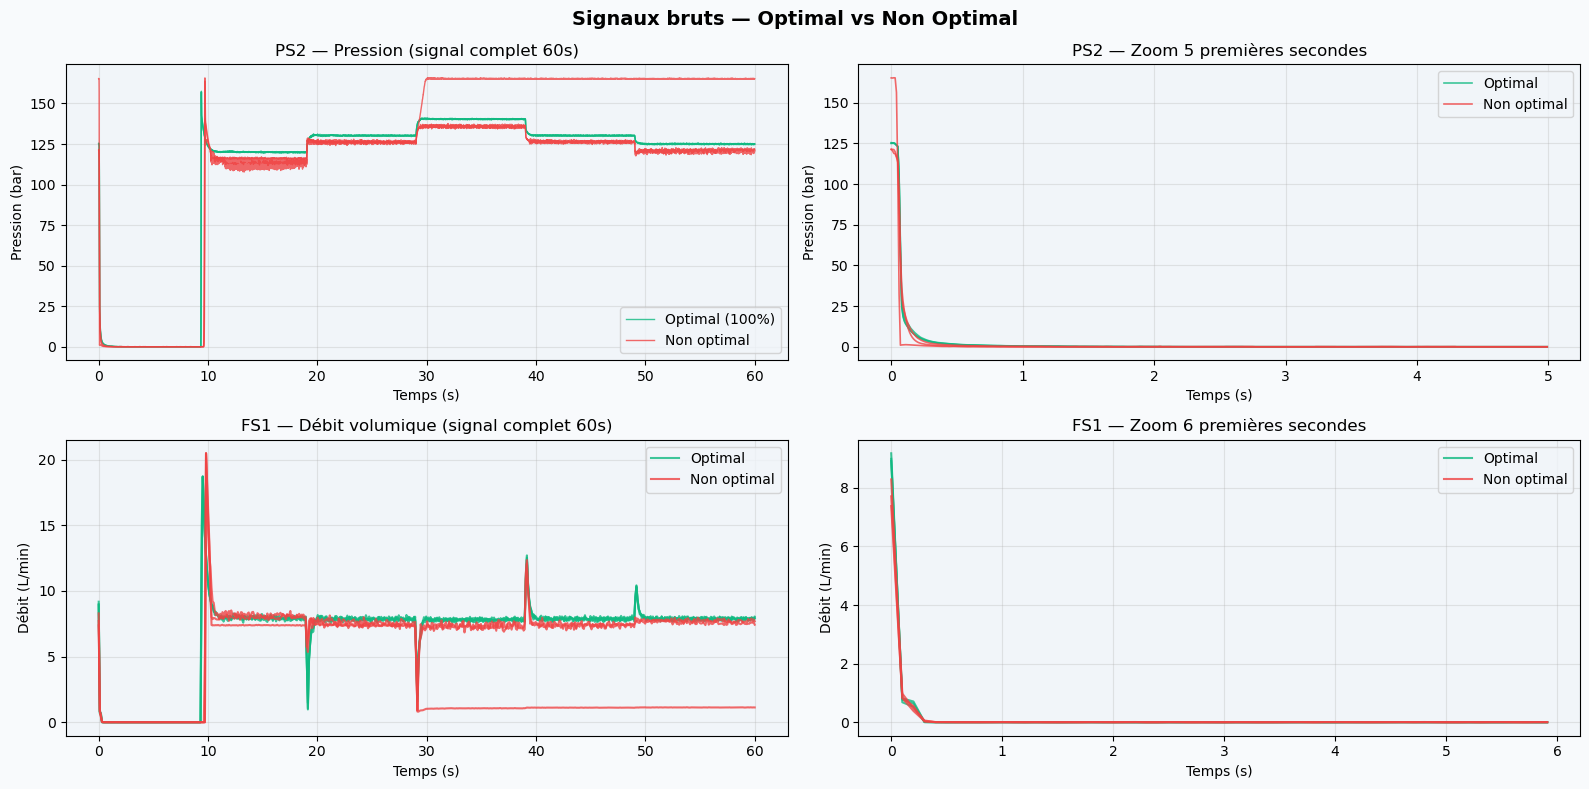

Figure sauvegardée : eda_signals.png


In [33]:
# Sélection de 3 cycles représentatifs par classe
idx_opt  = profile[profile['valve_optimal'] == 1].index[:3]
idx_nopt = profile[profile['valve_optimal'] == 0].index[:3]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Signaux bruts — Optimal vs Non Optimal', fontsize=14, fontweight='bold')

# ─ PS2 : signal complet ─
ax = axes[0, 0]
x_ps2 = np.linspace(0, 60, 6000)
for i, idx in enumerate(idx_opt):
    ax.plot(x_ps2, ps2.iloc[idx].values, color='#10b981', alpha=0.8, linewidth=1,
            label='Optimal (100%)' if i == 0 else '')
for i, idx in enumerate(idx_nopt):
    ax.plot(x_ps2, ps2.iloc[idx].values, color='#ef4444', alpha=0.8, linewidth=1,
            label='Non optimal' if i == 0 else '')
ax.set_title('PS2 — Pression (signal complet 60s)')
ax.set_xlabel('Temps (s)'); ax.set_ylabel('Pression (bar)')
ax.legend(); ax.grid(True, alpha=0.3)

# ─ PS2 : zoom sur les 5 premières secondes ─
ax = axes[0, 1]
n = 500  # 5s à 100Hz
for i, idx in enumerate(idx_opt):
    ax.plot(x_ps2[:n], ps2.iloc[idx, :n].values, color='#10b981', alpha=0.8,
            linewidth=1.2, label='Optimal' if i == 0 else '')
for i, idx in enumerate(idx_nopt):
    ax.plot(x_ps2[:n], ps2.iloc[idx, :n].values, color='#ef4444', alpha=0.8,
            linewidth=1.2, label='Non optimal' if i == 0 else '')
ax.set_title('PS2 — Zoom 5 premières secondes')
ax.set_xlabel('Temps (s)'); ax.set_ylabel('Pression (bar)')
ax.legend(); ax.grid(True, alpha=0.3)

# ─ FS1 : signal complet ─
ax = axes[1, 0]
x_fs1 = np.linspace(0, 60, 600)
for i, idx in enumerate(idx_opt):
    ax.plot(x_fs1, fs1.iloc[idx].values, color='#10b981', alpha=0.8, linewidth=1.5,
            label='Optimal' if i == 0 else '')
for i, idx in enumerate(idx_nopt):
    ax.plot(x_fs1, fs1.iloc[idx].values, color='#ef4444', alpha=0.8, linewidth=1.5,
            label='Non optimal' if i == 0 else '')
ax.set_title('FS1 — Débit volumique (signal complet 60s)')
ax.set_xlabel('Temps (s)'); ax.set_ylabel('Débit (L/min)')
ax.legend(); ax.grid(True, alpha=0.3)

# ─ FS1 : zoom ─
ax = axes[1, 1]
n_fs1 = 60  # 6s à 10Hz
for i, idx in enumerate(idx_opt):
    ax.plot(x_fs1[:n_fs1], fs1.iloc[idx, :n_fs1].values, color='#10b981', alpha=0.8,
            linewidth=1.5, label='Optimal' if i == 0 else '')
for i, idx in enumerate(idx_nopt):
    ax.plot(x_fs1[:n_fs1], fs1.iloc[idx, :n_fs1].values, color='#ef4444', alpha=0.8,
            linewidth=1.5, label='Non optimal' if i == 0 else '')
ax.set_title('FS1 — Zoom 6 premières secondes')
ax.set_xlabel('Temps (s)'); ax.set_ylabel('Débit (L/min)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_signals.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : eda_signals.png")


## 10. Distribution des statistiques par cycle

On calcule la **moyenne** et l'**écart-type** de chaque cycle pour PS2 et FS1,  
puis on compare leur distribution entre les deux classes.  
Si les distributions sont séparées → ces features seront discriminantes pour le modèle.


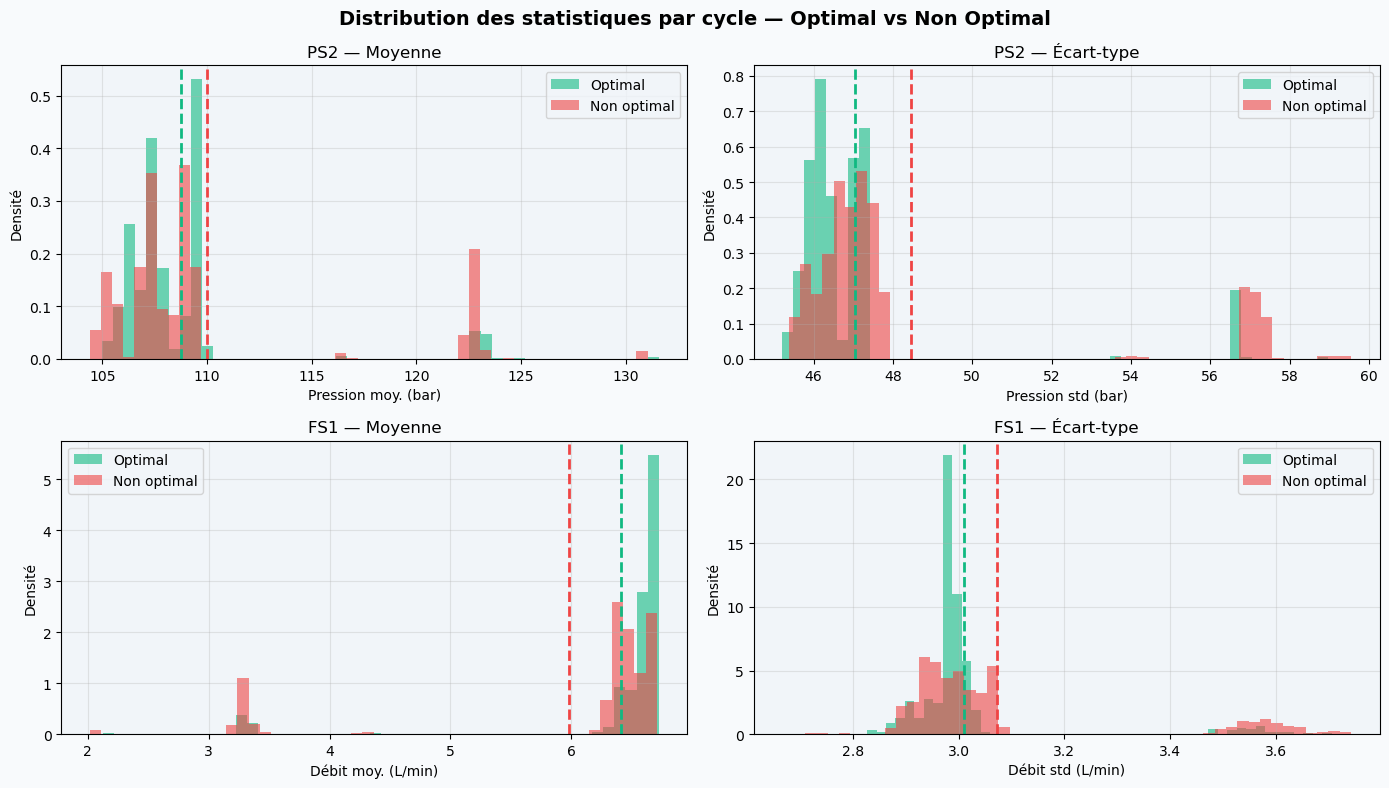

Figure sauvegardée : eda_distributions.png


In [34]:
# Calcul des stats par cycle
ps2_mean = ps2.mean(axis=1)
ps2_std  = ps2.std(axis=1)
fs1_mean = fs1.mean(axis=1)
fs1_std  = fs1.std(axis=1)

mask_opt  = profile['valve_optimal'] == 1
mask_nopt = profile['valve_optimal'] == 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Distribution des statistiques par cycle — Optimal vs Non Optimal',
             fontsize=14, fontweight='bold')

for ax, data, title, xlabel in zip(
    axes.flatten(),
    [ps2_mean, ps2_std, fs1_mean, fs1_std],
    ['PS2 — Moyenne', 'PS2 — Écart-type', 'FS1 — Moyenne', 'FS1 — Écart-type'],
    ['Pression moy. (bar)', 'Pression std (bar)', 'Débit moy. (L/min)', 'Débit std (L/min)']
):
    ax.hist(data[mask_opt],  bins=50, color='#10b981', alpha=0.6, label='Optimal',     density=True)
    ax.hist(data[mask_nopt], bins=50, color='#ef4444', alpha=0.6, label='Non optimal', density=True)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Densité')
    ax.legend(); ax.grid(True, alpha=0.3)
    # Affichage des moyennes de chaque groupe
    ax.axvline(data[mask_opt].mean(),  color='#10b981', linestyle='--', linewidth=2)
    ax.axvline(data[mask_nopt].mean(), color='#ef4444', linestyle='--', linewidth=2)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : eda_distributions.png")


sur l'écart-type de PS2, on voit des pics rouges isolés vers la droite (56-58 bar). Cela signifie qu'une forte instabilité de pression est un signe très clair d'une valve défaillante.

## 11. Corrélation entre les variables cibles

On examine si la dégradation de la valve est corrélée avec les autres composants.


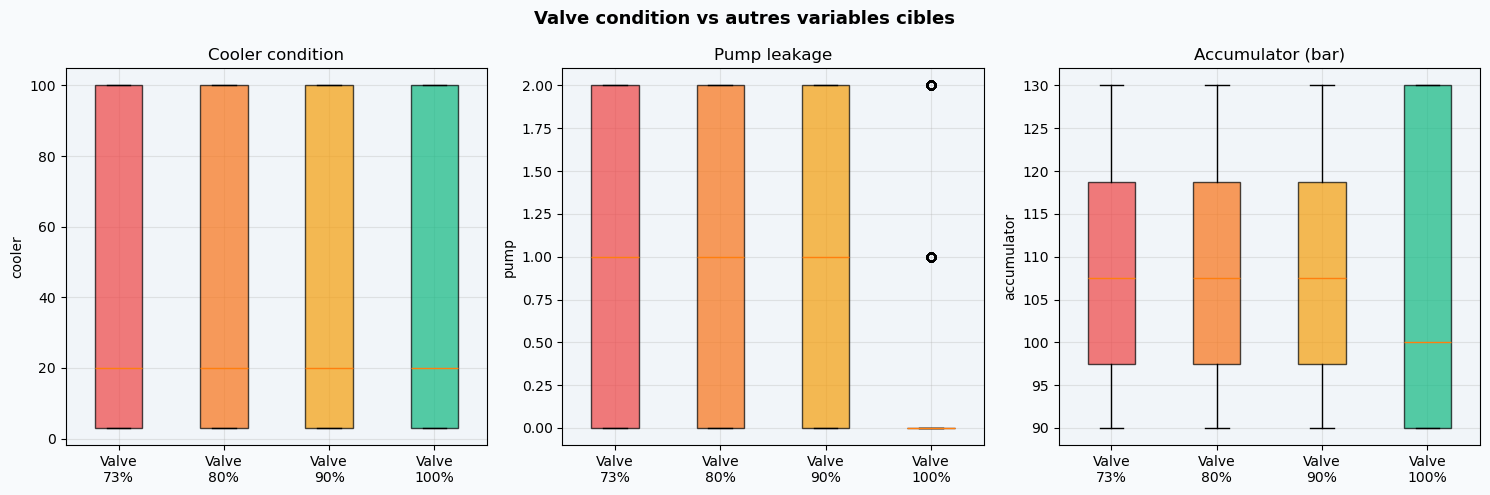

Figure sauvegardée : eda_correlations.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Valve condition vs autres variables cibles', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes, 
                           ['cooler', 'pump', 'accumulator'],
                           ['Cooler condition', 'Pump leakage', 'Accumulator (bar)']):
    # Boxplot : une boite par valeur de valve
    data_by_valve = [profile[profile['valve'] == v][col].values 
                     for v in sorted(profile['valve'].unique())]
    bp = ax.boxplot(data_by_valve, patch_artist=True,
                    labels=[f'Valve\n{v}%' for v in sorted(profile['valve'].unique())])
    colors_box = ['#ef4444', '#f97316', '#f59e0b', '#10b981']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(title); ax.set_ylabel(col); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : eda_correlations.png")


on remarque ici que la valve n'est pas correlelr avec les autres varibles conclusion:
La dégradation de la valve est indépendante des autres composants. Le modèle devra donc se baser uniquement sur les signaux PS2 et FS1 pour prédire l'état de la valve, pas sur les autres variables cibles.

## 12. Résumé de l'EDA

### Ce qu'on a appris

| Aspect | Observation |
|--------|-------------|
| **Nb cycles total** | 2205 |
| **Train (contrainte)** | 2000 premiers cycles |
| **Test final** | 205 cycles restants |
| **NaN** | Aucun |
| **Classes** | Bien équilibrées (51% / 49%) |
| **PS2** | 6000 features brutes par cycle (100 Hz × 60s) |
| **FS1** | 600 features brutes par cycle (10 Hz × 60s) |

### Décisions pour la prochaine étape (Feature Engineering)

1. **Les signaux bruts sont trop larges** (6000 + 600 colonnes) → on extrait des **statistiques par cycle**
2. **Features à extraire** : mean, std, min, max, median, Q25, Q75, skewness, kurtosis
3. **Stable flag** : à inclure comme feature ou à utiliser pour filtrer
4. **Pas besoin de rééquilibrage** des classes (ratio ≈ 1)
5. **Split** : index < 2000 → train | index >= 2000 → test (pas de shuffle !)


In [ ]:
print("─── PS2 ───")
print(f"  Shape       : {ps2.shape}")
print(f"  Durée cycle : {ps2.shape[1] / 100} secondes (100 Hz)")
print(f"  Dtype       : {ps2.dtypes.unique()}")
print(f"  Mémoire     : {ps2.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n─── FS1 ───")
print(f"  Shape       : {fs1.shape}")
print(f"  Durée cycle : {fs1.shape[1] / 10} secondes (10 Hz)")
print(f"  Dtype       : {fs1.dtypes.unique()}")
print(f"  Mémoire     : {fs1.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\n─── Profile ───")
print(f"  Shape       : {profile.shape}")
profile.dtypes


─── PS2 ───
  Shape       : (2205, 6000)
  Durée cycle : 60.0 secondes (100 Hz)
  Dtype       : [dtype('float64')]
  Mémoire     : 105.8 MB

─── FS1 ───
  Shape       : (2205, 600)
  Durée cycle : 60.0 secondes (10 Hz)
  Dtype       : [dtype('float64')]
  Mémoire     : 10.6 MB

─── Profile ───
  Shape       : (2205, 5)


cooler         int64
valve          int64
pump           int64
accumulator    int64
stable         int64
dtype: object